In [1]:
# Import libraries
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

## 1. Load YOLO Model

In [12]:
# Load model
model_path = "../checkpoints/my_best.pt"
model = YOLO(model_path)
model2 = YOLO("../checkpoints/yolov8m_psg.pt")

print(f"Model loaded from: {model_path}")
print(f"Model type: {model.task}")
print(f"Number of classes: {len(model.names)}")
print(f"\nClass names: {model.names}")

Model loaded from: ../checkpoints/my_best.pt
Model type: detect
Number of classes: 133

Class names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toil

## 2. Load and Display Test Image

Image path: yolo_augmentation/images/000000581930.jpg
Image size: (1920, 1080)
Image shape: (1080, 1920, 3)


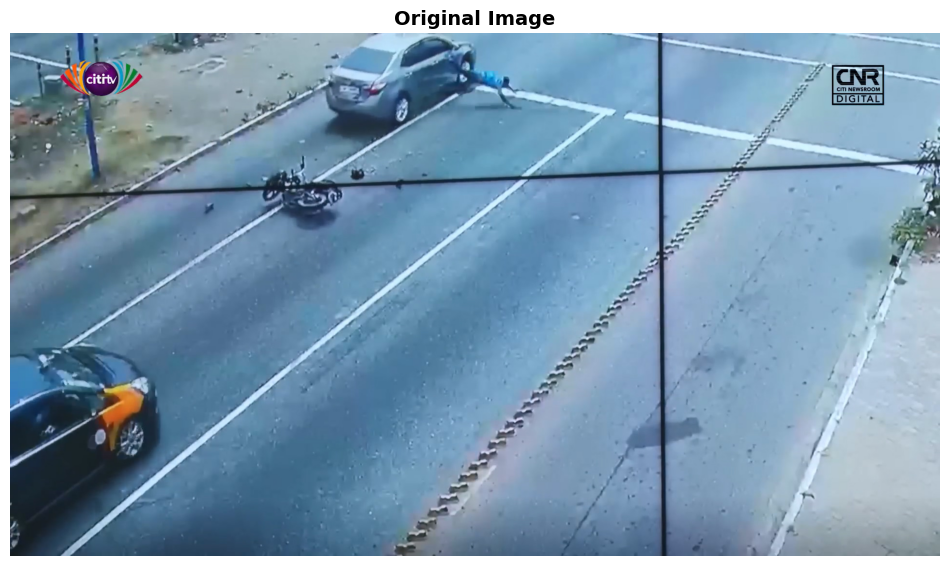

In [3]:
# Load image
image_path = "yolo_augmentation/images/000000581930.jpg"
img = Image.open(image_path)
img_array = np.array(img)

print(f"Image path: {image_path}")
print(f"Image size: {img.size}")
print(f"Image shape: {img_array.shape}")

# Display original image
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## 3. Run Detection

In [9]:
image_path="yolo_augmentation/images/000000581966.jpg"

In [15]:
# Run inference
results = model(image_path, conf=0.25, iou=0.45)

# Get detection results
result = results[0]

print(f"Number of detections: {len(result.boxes)}")
print(f"\nDetection details:")
print(f"Boxes shape: {result.boxes.xyxy.shape}")
print(f"Confidences shape: {result.boxes.conf.shape}")
print(f"Classes shape: {result.boxes.cls.shape}")


image 1/1 /mnt/f/gdrive/Takeout/Drive/School/4 Fourth year/BCTN/code/sgg-feedback/sgg/my_script/yolo_augmentation/images/000000581966.jpg: 384x640 24 persons, 1 bicycle, 2 cars, 13 motorcycles, 1 bus, 3 trucks, 1 road, 32.9ms
Speed: 4.3ms preprocess, 32.9ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)
Number of detections: 45

Detection details:
Boxes shape: torch.Size([45, 4])
Confidences shape: torch.Size([45])
Classes shape: torch.Size([45])


## 4. Visualize Detection Results

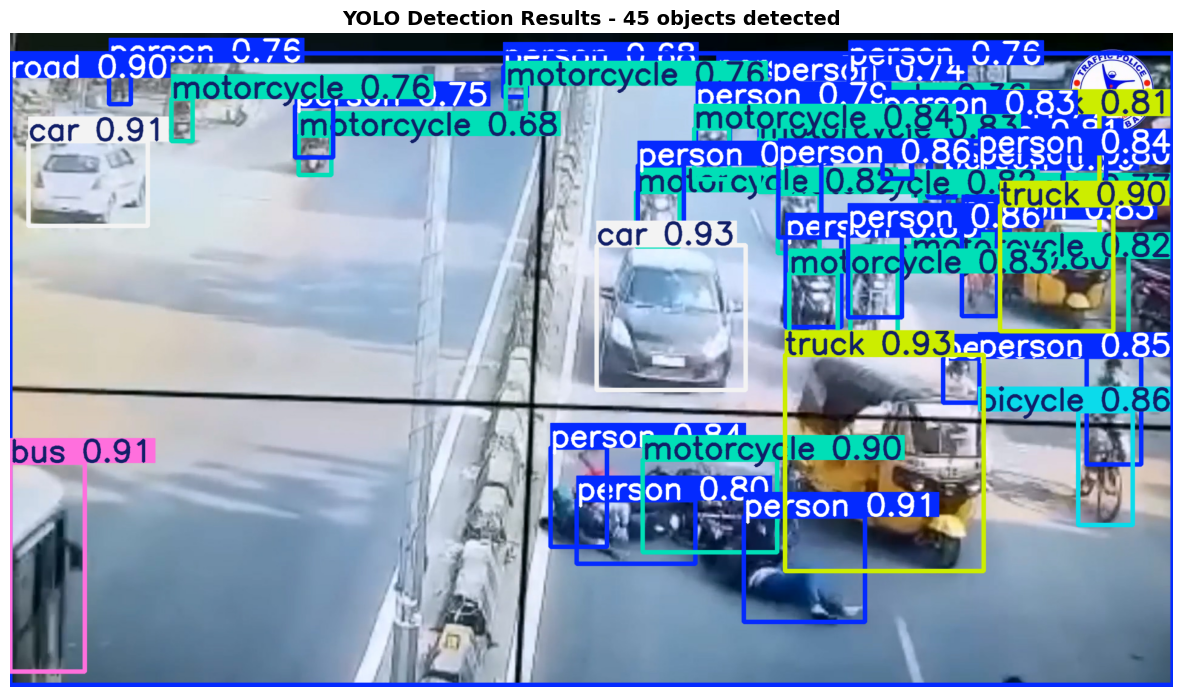

In [16]:
# Plot results with YOLO built-in visualization
annotated_img = result.plot()

# Convert BGR to RGB
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(15, 10))
plt.imshow(annotated_img_rgb)
plt.title(f'YOLO Detection Results - {len(result.boxes)} objects detected', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## 5. Print Detection Details

In [ ]:
# Print detailed detection information
print("\n" + "="*80)
print("DETECTION DETAILS")
print("="*80)

boxes = result.boxes
for idx, (box, conf, cls) in enumerate(zip(boxes.xyxy, boxes.conf, boxes.cls)):
    x1, y1, x2, y2 = box.cpu().numpy()
    confidence = conf.cpu().numpy()
    class_id = int(cls.cpu().numpy())
    class_name = model.names[class_id]
    
    print(f"\n{idx + 1}. {class_name} (ID: {class_id})")
    print(f"   Confidence: {confidence:.3f}")
    print(f"   BBox: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")
    print(f"   Size: {x2-x1:.1f} x {y2-y1:.1f}")

## 6. Custom Visualization with Matplotlib

In [ ]:
import matplotlib.patches as patches

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.imshow(img)

# Generate colors
colors = plt.cm.tab20(np.linspace(0, 1, len(model.names)))

# Draw boxes
boxes = result.boxes
for box, conf, cls in zip(boxes.xyxy, boxes.conf, boxes.cls):
    x1, y1, x2, y2 = box.cpu().numpy()
    confidence = conf.cpu().numpy()
    class_id = int(cls.cpu().numpy())
    class_name = model.names[class_id]
    
    # Get color
    color = colors[class_id]
    
    # Draw rectangle
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                            linewidth=3, edgecolor=color, 
                            facecolor='none')
    ax.add_patch(rect)
    
    # Add label
    label = f"{class_name} {confidence:.2f}"
    ax.text(x1, y1-5, label,
           bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.8),
           fontsize=12, color='white', weight='bold')

ax.set_title(f'YOLO Detection - {len(boxes)} objects', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Statistics and Summary

In [ ]:
from collections import Counter

# Count classes
class_counts = Counter()
for cls in result.boxes.cls:
    class_id = int(cls.cpu().numpy())
    class_name = model.names[class_id]
    class_counts[class_name] += 1

# Display statistics
print("\n" + "="*60)
print("DETECTION STATISTICS")
print("="*60)
print(f"\nTotal objects detected: {len(result.boxes)}")
print(f"\nObjects by class:")
for class_name, count in class_counts.most_common():
    print(f"  - {class_name}: {count}")

# Average confidence
avg_conf = result.boxes.conf.mean().cpu().numpy()
print(f"\nAverage confidence: {avg_conf:.3f}")

# Plot class distribution
if len(class_counts) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    
    bars = ax.bar(classes, counts, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title('Detection Distribution by Class', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}',
               ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 8. Test on Multiple Images

In [ ]:
# Test on multiple images
test_images = [
    "yolo_augmentation/images/000000581930.jpg",
    "yolo_augmentation/images/000000581933.jpg",
    # Add more images here
]

# Filter existing images
test_images = [img for img in test_images if os.path.exists(img)]

print(f"Testing on {len(test_images)} images...\n")

for img_path in test_images:
    print(f"\nProcessing: {img_path}")
    
    # Run detection
    results = model(img_path, conf=0.25)
    result = results[0]
    
    # Display
    annotated = result.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_rgb)
    plt.title(f'{os.path.basename(img_path)} - {len(result.boxes)} objects', 
             fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()
    
    print(f"Detected {len(result.boxes)} objects")

## 9. Save Results

In [ ]:
# Save annotated image
output_dir = "yolo_augmentation/detection_results"
os.makedirs(output_dir, exist_ok=True)

# Get filename
filename = os.path.basename(image_path)
output_path = os.path.join(output_dir, f"detected_{filename}")

# Save
results[0].save(output_path)
print(f"Results saved to: {output_path}")

# Save detection info to JSON
import json

detection_data = {
    'image': image_path,
    'model': model_path,
    'num_detections': len(result.boxes),
    'detections': []
}

boxes = result.boxes
for box, conf, cls in zip(boxes.xyxy, boxes.conf, boxes.cls):
    x1, y1, x2, y2 = box.cpu().numpy()
    detection_data['detections'].append({
        'class_id': int(cls.cpu().numpy()),
        'class_name': model.names[int(cls.cpu().numpy())],
        'confidence': float(conf.cpu().numpy()),
        'bbox': [float(x1), float(y1), float(x2), float(y2)]
    })

json_path = os.path.join(output_dir, f"detected_{filename.replace('.jpg', '.json')}")
with open(json_path, 'w') as f:
    json.dump(detection_data, f, indent=2)

print(f"Detection data saved to: {json_path}")

## 10. Change Detection Parameters

In [ ]:
# Test with different confidence thresholds
conf_thresholds = [0.1, 0.25, 0.5, 0.7]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, conf_thresh in enumerate(conf_thresholds):
    # Run detection
    results = model(image_path, conf=conf_thresh)
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    
    # Display
    axes[idx].imshow(annotated_rgb)
    axes[idx].set_title(f'Confidence threshold: {conf_thresh} ({len(results[0].boxes)} objects)', 
                       fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()